# ASX Stock Performance Predictor
 A machine learning project to predict next-day stock price direction for ASX-listed companies.


## v10 Changes
- Applied ascending sort for correct train/test ordering (train on old, test on recent)
- All other features same as v9
- Result: 54% — up from 50.8% (v9), best legitimate result so far
- Jump attributed to correct temporal ordering — model now learns historical patterns 
  and tests on unseen recent data, a more realistic evaluation
- Conclusion: ascending sort improves accuracy on recent data, try XGBoost in v11

## 1. Install & Import Libraries


In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import sqlite3

## 2. Download ASX Stock Data



In [16]:
ticker = input("Enter ASX ticker symbol (e.g. For Macquarie Group Enter: MQG): ")
stock = yf.Ticker(ticker.upper() + ".AX")
df = stock.history(period="5y") 
df = df.sort_index(ascending=False)
df.index = df.index.tz_localize(None)
df.head(10)

Enter ASX ticker symbol (e.g. For Macquarie Group Enter: MQG):  mqg


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-03-09,192.399994,196.139999,189.869995,195.449997,1127707,0.0,0.0
2026-03-06,196.699997,201.279999,194.800003,200.300003,979569,0.0,0.0
2026-03-05,195.089996,198.860001,194.539993,198.860001,1246062,0.0,0.0
2026-03-04,196.029999,196.899994,191.529999,191.529999,1103437,0.0,0.0
2026-03-03,200.210007,202.440002,195.779999,196.470001,1168746,0.0,0.0
2026-03-02,204.009995,204.494995,198.500000,199.860001,1461442,0.0,0.0
2026-02-27,210.000000,213.639999,209.839996,213.479996,1178563,0.0,0.0
2026-02-26,211.000000,211.100006,208.880005,209.550003,580711,0.0,0.0
2026-02-25,207.699997,208.190002,205.679993,207.119995,959862,0.0,0.0


## 3. Store Data in SQLite Database



In [17]:
# Connect to local SQLite database
conn = sqlite3.connect("asx_stocks.db")
df.to_sql(ticker.lower(), conn, if_exists="replace", index=True)
print(f"Data saved for {ticker}.AX!")

Data saved for mqg.AX!


In [18]:
# Query database to check data was saved correctly
query = f"""
SELECT * FROM {ticker.lower()}
ORDER BY "Date" DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
print(result)

                  Date        Open        High         Low       Close  \
0  2026-03-09 00:00:00  192.399994  196.139999  189.869995  195.449997   
1  2026-03-06 00:00:00  196.699997  201.279999  194.800003  200.300003   
2  2026-03-05 00:00:00  195.089996  198.860001  194.539993  198.860001   
3  2026-03-04 00:00:00  196.029999  196.899994  191.529999  191.529999   
4  2026-03-03 00:00:00  200.210007  202.440002  195.779999  196.470001   
5  2026-03-02 00:00:00  204.009995  204.494995  198.500000  199.860001   
6  2026-02-27 00:00:00  210.000000  213.639999  209.839996  213.479996   
7  2026-02-26 00:00:00  211.000000  211.100006  208.880005  209.550003   
8  2026-02-25 00:00:00  207.699997  208.190002  205.679993  207.119995   
9  2026-02-24 00:00:00  204.500000  207.630005  201.250000  206.490005   

    Volume  Dividends  Stock Splits  
0  1127707        0.0           0.0  
1   979569        0.0           0.0  
2  1246062        0.0           0.0  
3  1103437        0.0           0

## 4. Engineer Features



In [19]:
# Calculate moving averages (MA) to smooth out short term price noise
df["MA7"] = df["Close"].rolling(window=7).mean()
df["MA30"] = df["Close"].rolling(window=30).mean()

# Calculate momentum over last 7 days
df["Momentum"] = df["Close"] - df["Close"].shift(7)

# Calculate RSI (Relative Strength Index) over 14 days (check whether a stock is overbought or oversold)
delta = df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
df["RSI"] = 100 - (100 / (1 + avg_gain / avg_loss))

# Calculate Bollinger Bands — measures price volatility
# Upper and lower bands are 2 standard deviations from the 20 day moving average
df["BB_Middle"] = df["Close"].rolling(window=20).mean()
df["BB_Upper"] = df["BB_Middle"] + 2 * df["Close"].rolling(window=20).std()
df["BB_Lower"] = df["BB_Middle"] - 2 * df["Close"].rolling(window=20).std()
df["BB_Width"] = df["BB_Upper"] - df["BB_Lower"]

# Calculate MACD (Moving Average Convergence Divergence)
# Measures momentum by comparing 12 and 26 day exponential moving averages
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = ema12 - ema26
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

# HL_Spread — difference between daily high and low, captures intraday volatility
df["HL_Spread"] = df["High"] - df["Low"]

# OC_Spread — difference between close and open, captures intraday price direction
df["OC_Spread"] = df["Close"] - df["Open"]

# Calculate Target Variable: 1 if tomorrows price is higher than today, 0 if not
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

df.head(10)


,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA7,MA30,Momentum,...,BB_Middle,BB_Upper,BB_Lower,BB_Width,MACD,MACD_Signal,MACD_Hist,HL_Spread,OC_Spread,Target
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-09,192.399994,196.139999,189.869995,195.449997,1127707,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,6.270004,3.050003,1
2026-03-06,196.699997,201.279999,194.800003,200.300003,979569,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.386895,0.077379,0.309516,6.479996,3.600006,0
2026-03-05,195.089996,198.860001,194.539993,198.860001,1246062,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.570737,0.176051,0.394686,4.320007,3.770004,0
2026-03-04,196.029999,196.899994,191.529999,191.529999,1103437,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.123539,0.165548,-0.042009,5.369995,-4.500000,1
2026-03-03,200.210007,202.440002,195.779999,196.470001,1168746,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.165837,0.165606,0.000231,6.660004,-3.740005,1
2026-03-02,204.009995,204.494995,198.500000,199.860001,1461442,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.467513,0.225987,0.241526,5.994995,-4.149994,1
2026-02-27,210.000000,213.639999,209.839996,213.479996,1178563,0.0,0.0,199.421428,NaN,NaN,...,NaN,NaN,NaN,NaN,1.785037,0.537797,1.247240,3.800003,3.479996,0
2026-02-26,211.000000,211.100006,208.880005,209.550003,580711,0.0,0.0,201.435715,NaN,14.100006,...,NaN,NaN,NaN,NaN,2.483439,0.926926,1.556513,2.220001,-1.449997,0
2026-02-25,207.699997,208.190002,205.679993,207.119995,959862,0.0,0.0,202.409999,NaN,6.819992,...,NaN,NaN,NaN,NaN,2.808472,1.303235,1.505237,2.510010,-0.580002,0


In [20]:
# Drop rows with missing values, check shape
df = df.dropna()
df = df.sort_index(ascending=True)
df.shape

(1236, 21)

## 5. Train the Model



In [21]:
# Define features and target
features = ["Close", "MA7", "MA30", "Momentum", "Volume", "RSI", "BB_Width", "HL_Spread"]
X = df[features]
y = df["Target"]


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_train.shape, X_test.shape

((988, 8), (248, 8))

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Test different n_estimators to find optimal number of trees
param_grid = {"n_estimators": list(range(100, 525, 25))}
grid = GridSearchCV(RandomForestClassifier(random_state=6), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best accuracy:", grid.best_score_)

# Set model to best found parameters
model = grid.best_estimator_
model_name = f"Random Forest {grid.best_params_['n_estimators']} trees (GridSearchCV)"
print("Model Trained!")

Best params: {'n_estimators': 250}
Best accuracy: 0.5021022406809209
Model Trained!


## 6. Evaluate & Visualise Results



In [24]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on test set
y_pred = model.predict(X_test)

# Check accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5403225806451613
              precision    recall  f1-score   support

           0       0.52      0.78      0.62       122
           1       0.59      0.31      0.41       126

    accuracy                           0.54       248
   macro avg       0.56      0.54      0.52       248
weighted avg       0.56      0.54      0.51       248



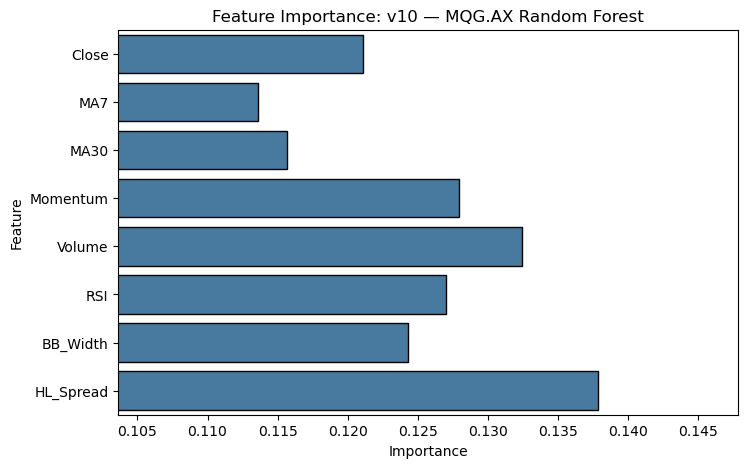

In [27]:
# Plot feature importance - visualise which features the model relied on most
feature_importance = pd.Series(model.feature_importances_, index=features)
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, color="#397dad", edgecolor="black")
plt.title(f"Feature Importance: v10 — {ticker.upper()}.AX Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.xlim(feature_importance.min() - 0.01, feature_importance.max() + 0.01)
plt.show()

In [28]:
conn2 = sqlite3.connect("asx_stocks.db")
log = pd.DataFrame({
    "version": ["v10"],
    "accuracy": [accuracy_score(y_test, y_pred)],
    "model": [model_name],
    "notes": ["Ascending sort applied — accuracy improved from 50.8% (v9) to 54%, best clean result"]
})
log.to_sql("progress_log", conn2, if_exists="append", index=False)
conn2.close()
print("v10 logged!")

v10 logged!
